In [ ]:
!pip install pyspark -q

In [ ]:
import time
import pandas as pd
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("COMP3610_Assignment3_NYC_Taxi")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("Warn")
print(f"Spark version: {spark.version}")
print(f"Application name: {spark.sparkContext.appName}")

Spark version: 4.0.2
Application name: COMP3610_Assignment3_NYC_Taxi


In [ ]:
DATA_PATH = "/content/yellow_tripdata_2024-01.parquet"

spark_start = time.time()
df_raw = spark.read.parquet(DATA_PATH)
spark_row_count = df_raw.count()
spark_load_time = time.time() - spark_start

pandas_start = time.time()
df_pandas = pd.read_parquet(DATA_PATH)
pandas_load_time = time.time() - pandas_start

print(f"\nLoad Time Comparison")
print(f"Spark  load time : {spark_load_time:.2f}s  ({spark_row_count:,} rows)")
print(f"Pandas load time : {pandas_load_time:.2f}s  ({len(df_pandas):,} rows)")
print(f"\nInterpretation: Spark has higher overhead on a single machine due to JVM")
print(f"startup and task scheduling. However, Spark scales across clusters and handles")
print(f"datasets far exceeding available RAM, making it essential for big data workloads.")


Load Time Comparison
Spark  load time : 14.87s  (2,964,624 rows)
Pandas load time : 1.43s  (2,964,624 rows)

Interpretation: Spark has higher overhead on a single machine due to JVM
startup and task scheduling. However, Spark scales across clusters and handles
datasets far exceeding available RAM, making it essential for big data workloads.


In [ ]:
print(f"DataFrame Schema")
df_raw.printSchema()
print(f"\nTotal Rows: {spark_row_count:,}")
print(f"\nPartition Information: {df_raw.rdd.getNumPartitions()}")

DataFrame Schema
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)


Total Rows: 2,964,624

Partition Information: 2


In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

critical_cols = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "fare_amount",
    "trip_distance"
]

initial_count = df_raw.count()
print(f"Initial Row Count: {initial_count:,}")

df_no_nulls = df_raw.dropna(subset = critical_cols)
after_null_drop = df_no_nulls.count()
print(f"After Null Drop: {after_null_drop:,} (removed {initial_count - after_null_drop:,}")

df_filtered = df_no_nulls.filter(
    (F.col("trip_distance") > 0) &
    (F.col("fare_amount") >= 0) &
    (F.col("fare_amount") <= 500) &
    (F.col("tpep_dropoff_datetime") > F.col("tpep_pickup_datetime"))
)

after_filter = df_filtered.count()
print(f"After Filter: {after_filter:,} (removed {after_null_drop - after_filter:,}")
print(f"Total rows removed: {initial_count - after_filter:,}")

Initial Row Count: 2,964,624
After Null Drop: 2,964,624 (removed 0
After Filter: 2,870,046 (removed 94,578
Total rows removed: 94,578


In [ ]:
df_clean = df_filtered.withColumn(
    "trip_duration_minutes",
    (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60
).withColumn(
    "trip_speed_mph",
    F.when(
        F.col("trip_duration_minutes") > 0,
        F.col("trip_distance") / (F.col("trip_duration_minutes") / 60.0)
    ).otherwise(F.lit(None).cast(DoubleType()))
).withColumn(
    "pickup_hour",
    F.hour("tpep_pickup_datetime")
).withColumn(
    "pickup_day_of_week",
    F.dayofweek("tpep_pickup_datetime")
).withColumn(
    "tip_percentage",
    F.when(
        F.col("fare_amount") > 0,
        (F.col("tip_amount") / F.col("fare_amount")) * 100
    ).otherwise(F.lit(0.0))
)

print("Derived Columns:")
df_clean.select(
    "tpep_pickup_datetime", "trip_distance", "fare_amount",
    "trip_duration_minutes", "trip_speed_mph",
    "pickup_hour", "pickup_day_of_week", "tip_percentage"
).show(5, truncate=False)

print(f"\nClean row count: {df_clean.count():,}")


Derived Columns:
+--------------------+-------------+-----------+---------------------+------------------+-----------+------------------+------------------+
|tpep_pickup_datetime|trip_distance|fare_amount|trip_duration_minutes|trip_speed_mph    |pickup_hour|pickup_day_of_week|tip_percentage    |
+--------------------+-------------+-----------+---------------------+------------------+-----------+------------------+------------------+
|2024-01-01 00:57:55 |1.72         |17.7       |19.8                 |5.212121212121212 |0          |2                 |0.0               |
|2024-01-01 00:03:00 |1.8          |10.0       |6.6                  |16.363636363636363|0          |2                 |37.5              |
|2024-01-01 00:17:06 |4.7          |23.3       |17.916666666666668   |15.739534883720932|0          |2                 |12.875536480686694|
|2024-01-01 00:36:38 |1.4          |10.0       |8.3                  |10.120481927710843|0          |2                 |20.0              |
|20

In [ ]:
df_clean.createOrReplaceTempView("taxi_trips")
print("View 'taxi_trips' registered.")

View 'taxi_trips' registered.


In [ ]:
print("Query 1: Top 10 Busiest Pickup Hours")
q1 = spark.sql("""
    SELECT
        pickup_hour,
        COUNT(*)                        AS trip_count,
        ROUND(AVG(fare_amount), 2)      AS avg_fare,
        ROUND(AVG(tip_percentage), 2)   AS avg_tip_percent
    FROM taxi_trips
    GROUP BY pickup_hour
    ORDER BY trip_count DESC
    LIMIT 10
""")
q1.show()

print("Interpretation: \n\nEvening hours around 3 p.m onwards have the majority of trip volume, this is because of after work commuting.")
print("\nTip percentages tend to hover around 20% with the highest being ~2% more at night")

Query 1: Top 10 Busiest Pickup Hours
+-----------+----------+--------+---------------+
|pickup_hour|trip_count|avg_fare|avg_tip_percent|
+-----------+----------+--------+---------------+
|         18|    206281|   17.01|          22.78|
|         17|    200310|   18.12|          22.34|
|         16|    184968|   19.46|          21.83|
|         15|    184004|   19.11|           19.8|
|         19|    178810|   17.63|          22.86|
|         14|    178026|   19.27|           19.8|
|         13|    165355|   18.42|          19.78|
|         12|    159912|    17.8|          19.74|
|         21|    155910|   18.29|          21.88|
|         20|    155559|   18.05|          22.17|
+-----------+----------+--------+---------------+

Interpretation: 

Evening hours around 3 p.m onwards have the majority of trip volume, this is because of after work commuting.

Tip percentages tend to hover around 20% with the highest being ~2% more at night


In [ ]:
print("Query 2: Average trip speed by day of the week")
q2 = spark.sql("""
    SELECT
        CASE pickup_day_of_week
            WHEN 1 THEN 'Sunday'    WHEN 2 THEN 'Monday'
            WHEN 3 THEN 'Tuesday'   WHEN 4 THEN 'Wednesday'
            WHEN 5 THEN 'Thursday'  WHEN 6 THEN 'Friday'
            WHEN 7 THEN 'Saturday'
        END                                  AS day_of_week,
        ROUND(AVG(trip_speed_mph), 2)        AS avg_speed_mph,
        ROUND(AVG(trip_distance), 2)         AS avg_distance_miles,
        ROUND(AVG(trip_duration_minutes), 2) AS avg_duration_mins
    FROM taxi_trips
    WHERE trip_speed_mph IS NOT NULL
    GROUP BY pickup_day_of_week
    ORDER BY avg_speed_mph DESC
""")
q2.show()
print("Interpretation: \n\nThere are higher average speeds on Tuesdays and Mondays because there is less congestion and traffic which allows for higher speeds.")
print("\nIn the later end of the week, there is more traffic due to work commuting to and from, which lowers avg speed ")

Query 2: Average trip speed by day of the week
+-----------+-------------+------------------+-----------------+
|day_of_week|avg_speed_mph|avg_distance_miles|avg_duration_mins|
+-----------+-------------+------------------+-----------------+
|    Tuesday|        17.46|              4.25|            16.18|
|     Sunday|        15.97|               3.9|            14.32|
|     Monday|        13.85|              3.77|            15.85|
|     Friday|        13.41|              3.68|            15.93|
|   Saturday|        13.26|              3.39|             14.9|
|   Thursday|        12.48|              3.54|            16.43|
|  Wednesday|        12.38|              3.61|            16.26|
+-----------+-------------+------------------+-----------------+

Interpretation: 

There are higher average speeds on Tuesdays and Mondays because there is less congestion and traffic which allows for higher speeds.

In the later end of the week, there is more traffic due to work commuting to and from

In [ ]:
print("Query 3: Top 5 Pickup Locations by Revenue per Day")
q3 = spark.sql("""
    WITH revenue_by_day_location AS (
        SELECT
            CASE pickup_day_of_week
                WHEN 1 THEN 'Sunday'    WHEN 2 THEN 'Monday'
                WHEN 3 THEN 'Tuesday'   WHEN 4 THEN 'Wednesday'
                WHEN 5 THEN 'Thursday'  WHEN 6 THEN 'Friday'
                WHEN 7 THEN 'Saturday'
            END                             AS day_of_week,
            pickup_day_of_week,
            PULocationID                    AS pickup_location,
            ROUND(SUM(total_amount), 2)     AS total_revenue,
            COUNT(*)                        AS trip_count
        FROM taxi_trips
        GROUP BY pickup_day_of_week, PULocationID
    ),
    ranked AS (
        SELECT *,
            RANK() OVER (
                PARTITION BY pickup_day_of_week
                ORDER BY total_revenue DESC
            ) AS revenue_rank
        FROM revenue_by_day_location
    )
    SELECT day_of_week, pickup_location, total_revenue, trip_count, revenue_rank
    FROM ranked
    WHERE revenue_rank <= 5
    ORDER BY pickup_day_of_week, revenue_rank
""")
q3.show(35, truncate=False)
print("Interpretation: \n\nA small set of high-traffic zones (JFK, LaGuardia, Midtown)")
print("dominate revenue across all days. Airport locations rank higher on weekends.")

Query 3: Top 5 Pickup Locations by Revenue per Day
+-----------+---------------+-------------+----------+------------+
|day_of_week|pickup_location|total_revenue|trip_count|revenue_rank|
+-----------+---------------+-------------+----------+------------+
|Sunday     |132            |1564287.93   |19526     |1           |
|Sunday     |138            |763398.54    |12038     |2           |
|Sunday     |230            |346553.95    |12736     |3           |
|Sunday     |186            |264131.38    |11092     |4           |
|Sunday     |79             |263467.74    |12263     |5           |
|Monday     |132            |2054606.73   |25282     |1           |
|Monday     |138            |1021138.28   |15656     |2           |
|Monday     |161            |460145.28    |19338     |3           |
|Monday     |236            |373008.89    |18502     |4           |
|Monday     |237            |372575.48    |19214     |5           |
|Tuesday    |132            |1794987.56   |22384     |1          

In [ ]:
print("Query 4: Cumulative Trip Count by Hour")
q4 = spark.sql("""
    WITH hourly_counts AS (
        SELECT pickup_hour, COUNT(*) AS trips_this_hour
        FROM taxi_trips
        GROUP BY pickup_hour
    ),
    cumulative AS (
        SELECT pickup_hour, trips_this_hour,
            SUM(trips_this_hour) OVER (
                ORDER BY pickup_hour
                ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
            ) AS cumulative_trips
        FROM hourly_counts
    )
    SELECT pickup_hour, trips_this_hour, cumulative_trips,
        ROUND(cumulative_trips * 100.0 / SUM(trips_this_hour) OVER (), 2) AS cumulative_pct
    FROM cumulative
    ORDER BY pickup_hour
""")
q4.show(24)

crossover = q4.filter(F.col("cumulative_pct") >= 50).orderBy("pickup_hour").first()
print(f"\n50% of daily trips completed by hour: {crossover['pickup_hour']}:00 ({crossover['cumulative_percent']}%)")

print("Interpretation: \n\nThe 50% threshold is crossed in the early afternoon around 3 pm, which means trip activity is concentrated to the later half of the day")


Query 4: Cumulative Trip Count by Hour
+-----------+---------------+----------------+--------------+
|pickup_hour|trips_this_hour|cumulative_trips|cumulative_pct|
+-----------+---------------+----------------+--------------+
|          0|          75247|           75247|          2.62|
|          1|          50490|          125737|          4.38|
|          2|          34976|          160713|          5.60|
|          3|          22947|          183660|          6.40|
|          4|          15284|          198944|          6.93|
|          5|          17495|          216439|          7.54|
|          6|          39415|          255854|          8.91|
|          7|          80870|          336724|         11.73|
|          8|         113506|          450230|         15.69|
|          9|         125619|          575849|         20.06|
|         10|         135425|          711274|         24.78|
|         11|         146754|          858028|         29.90|
|         12|         159912|  

In [ ]:
print("Query 5: Short vs Medium vs Long trip comparison")
q5 = spark.sql("""
    SELECT
        CASE
            WHEN trip_distance < 2   THEN 'Short (<2 miles)'
            WHEN trip_distance <= 10 THEN 'Medium (2-10 miles)'
            ELSE                          'Long (>10 miles)'
        END                              AS trip_category,
        COUNT(*)                         AS trip_count,
        ROUND(AVG(fare_amount), 2)       AS avg_fare,
        ROUND(AVG(trip_distance), 2)     AS avg_distance,
        ROUND(AVG(tip_percentage), 2)    AS avg_tip_percent
    FROM taxi_trips
    GROUP BY trip_category
    ORDER BY avg_distance
""")
q5.show()

print("Interpretation: \n\nShort Trips have the most trip count volume by far as well as the smallest fare")
print("\nThe tip percentage is the highest in the short followed by long")
print("\nLong trips have the highest avg fare as well as the least amount of trips")

Query 5: Short vs Medium vs Long trip comparison
+-------------------+----------+--------+------------+---------------+
|      trip_category|trip_count|avg_fare|avg_distance|avg_tip_percent|
+-------------------+----------+--------+------------+---------------+
|   Short (<2 miles)|   1642438|    9.91|        1.13|          23.07|
|Medium (2-10 miles)|   1002534|   22.18|        3.96|          18.57|
|   Long (>10 miles)|    225074|   64.65|        21.7|          21.93|
+-------------------+----------+--------+------------+---------------+

Interpretation: 

Short Trips have the most trip count volume by far as well as the smallest fare

The tip percentage is the highest in the short followed by long

Long trips have the highest avg fare as well as the least amount of trips


In [ ]:
def run_benchmark_query():
  return spark.sql("""
      SELECT pickup_hour, COUNT(*) AS trips, ROUND(AVG(fare_amount), 2) AS avg_fare
        FROM taxi_trips
        GROUP BY pickup_hour ORDER BY pickup_hour
    """).collect()

t0 = time.time()
run_benchmark_query()
time_before = time.time() - t0
print(f"Query time before optimization: {time_before:.2f}s")

df_clean.cache()
df_clean.count()

t1 = time.time()
run_benchmark_query()
time_after = time.time() - t1
print(f"Query time after optimization: {time_after:.2f}s")
print(f"Speedup: {time_before / time_after:.1f}x")

print("\nInterpretation: Caching stores the dataframe in memory so spark avoids rescanning the parquet files on every action, giving faster repeated queries")

Query time before optimization: 1.01s
Query time after optimization: 0.63s
Speedup: 1.6x

Interpretation: Caching stores the dataframe in memory so spark avoids rescanning the parquet files on every action, giving faster repeated queries


In [ ]:
OUTPUT_PATH = "/content/cleaned_taxi_partitioned"

print("Writing partitioned parquet files...")
t_write = time.time()
df_clean.write.mode("overwrite").partitionBy("pickup_hour").parquet(OUTPUT_PATH)
print(f"Write complete in {time.time() - t_write:.2f}s")

t_prune = time.time()
df_hour17 = spark.read.parquet(f"{OUTPUT_PATH}/pickup_hour=17")
count_17 = df_hour17.count()
print(f"\nRows in hour 17 partition  : {count_17:,}")
print(f"Read time (single partition): {time.time() - t_prune:.2f}s")

print("\nPartition pruning means spark reads 1 of 24 directories instead of the full dataset, reducing data scanned")

Writing partitioned parquet files...
Write complete in 25.08s

Rows in hour 17 partition  : 200,310
Read time (single partition): 0.41s


In [ ]:
print("Physical Execution Plan")
spark.sql("""
    SELECT pickup_hour, COUNT(*) AS trip_count,
           ROUND(AVG(fare_amount), 2) AS avg_fare
    FROM taxi_trips
    GROUP BY pickup_hour
    ORDER BY trip_count DESC
    LIMIT 10
""").explain(mode="simple")

Physical Execution Plan
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- TakeOrderedAndProject(limit=10, orderBy=[trip_count#7363L DESC NULLS LAST], output=[pickup_hour#114,trip_count#7363L,avg_fare#7364])
   +- HashAggregate(keys=[pickup_hour#114], functions=[count(1), avg(fare_amount#10)])
      +- Exchange hashpartitioning(pickup_hour#114, 200), ENSURE_REQUIREMENTS, [plan_id=2744]
         +- HashAggregate(keys=[pickup_hour#114], functions=[partial_count(1), partial_avg(fare_amount#10)])
            +- InMemoryTableScan [fare_amount#10, pickup_hour#114]
                  +- InMemoryRelation [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3L, trip_distance#4, RatecodeID#5L, store_and_fwd_flag#6, PULocationID#7, DOLocationID#8, payment_type#9L, fare_amount#10, extra#11, mta_tax#12, tip_amount#13, tolls_amount#14, improvement_surcharge#15, total_amount#16, congestion_surcharge#17, Airport_fee#18, trip_duration_minutes#112, trip_speed_mph#113, pic

In [ ]:
df_clean.unpersist()
print("Cache cleared")

Cache cleared


In [5]:
!pip install langchain langchain-community chromadb sentence-transformers pypdf matplotlib seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.

In [7]:
import os
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer
import chromadb
import matplotlib.pyplot as plt
import seaborn as sns

docs_path = "/content/docs"
pdf_files = [f for f in os.listdir(docs_path) if f.endswith(".pdf")]

print(f"Found {len(pdf_files)} PDFs:")
for f in pdf_files:
    print(f"  - {f}")

Found 5 PDFs:
  - stratplan_compplan.pdf
  - NYC-Vision-Zero-Investment.pdf
  - 25-38 NYC Delivery Worker Data Collection and Research Report.pdf
  - annual_report_2023.pdf
  - mta-annual-report-2023.3.pdf


In [9]:
all_documents = []
extraction_stats = []

for pdf_file in pdf_files:
    path = os.path.join(docs_path, pdf_file)
    try:
        loader = PyPDFLoader(path)
        pages = loader.load()
        total_chars = sum(len(p.page_content) for p in pages)
        all_documents.extend(pages)
        extraction_stats.append({
            "file": pdf_file,
            "pages": len(pages),
            "characters": total_chars,
            "avg_chars_per_page": total_chars // len(pages) if pages else 0
        })
        print(f"Worked {pdf_file}: {len(pages)} pages, {total_chars:,} chars")
    except Exception as e:
        print(f"No Worked {pdf_file}: FAILED — {e}")

total_pages = sum(s["pages"] for s in extraction_stats)
total_chars = sum(s["characters"] for s in extraction_stats)

print(f"Extraction Summary")
print(f"Total documents: {len(pdf_files)}")
print(f"Total pages: {total_pages}")
print(f"Total characters: {total_chars:,}")
print(f"Total doc chunks: {len(all_documents)}")

Worked stratplan_compplan.pdf: 39 pages, 107,844 chars
Worked NYC-Vision-Zero-Investment.pdf: 15 pages, 34,554 chars
Worked 25-38 NYC Delivery Worker Data Collection and Research Report.pdf: 104 pages, 164,461 chars
Worked annual_report_2023.pdf: 18 pages, 39,183 chars
Worked mta-annual-report-2023.3.pdf: 33 pages, 52,778 chars
Extraction Summary
Total documents : 5
Total pages     : 209
Total characters: 398,820
Total doc chunks: 209


Chunks with size 500: 1060
Chunks with size 1000: 562
Chunks with size 2000: 321


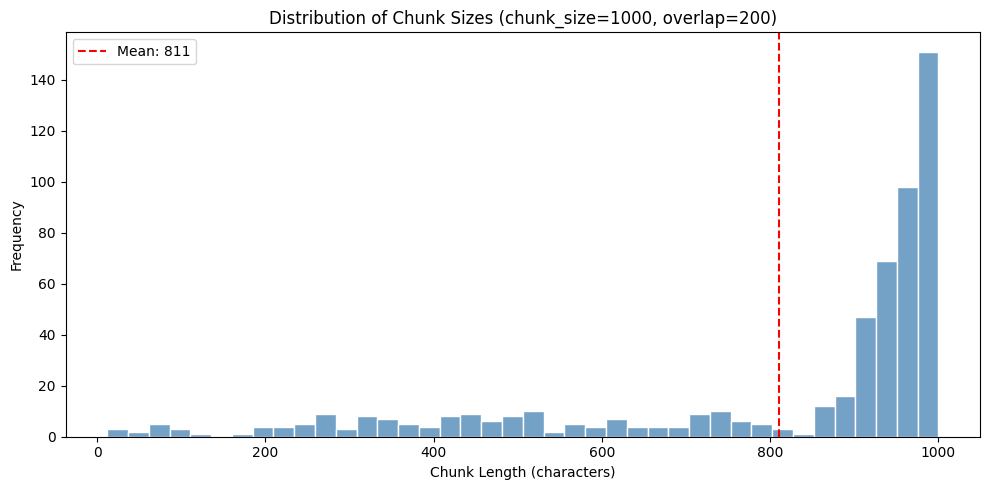


Min chunk size: 12
Max chunk size: 1000
Mean chunk size: 811


In [10]:
splitter_1000 = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks_1000 = splitter_1000.split_documents(all_documents)

splitter_500 = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
chunks_500 = splitter_500.split_documents(all_documents)

splitter_2000 = RecursiveCharacterTextSplitter(chunk_size=2000, chunk_overlap=400)
chunks_2000 = splitter_2000.split_documents(all_documents)

print(f"Chunks with size 500: {len(chunks_500)}")
print(f"Chunks with size 1000: {len(chunks_1000)}")
print(f"Chunks with size 2000: {len(chunks_2000)}")

chunk_lengths = [len(c.page_content) for c in chunks_1000]

plt.figure(figsize=(10, 5))
sns.histplot(chunk_lengths, bins=40, color="steelblue", edgecolor="white")
plt.title("Distribution of Chunk Sizes (chunk_size=1000, overlap=200)")
plt.xlabel("Chunk Length (characters)")
plt.ylabel("Frequency")
plt.axvline(x=sum(chunk_lengths)/len(chunk_lengths), color="red", linestyle="--", label=f"Mean: {sum(chunk_lengths)/len(chunk_lengths):.0f}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nMin chunk size: {min(chunk_lengths)}")
print(f"Max chunk size: {max(chunk_lengths)}")
print(f"Mean chunk size: {sum(chunk_lengths)/len(chunk_lengths):.0f}")

In [11]:
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

print("Loading embedding model")
embedding_fn = SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2")

chroma_client = chromadb.PersistentClient(path="/content/chroma_db")

try:
    chroma_client.delete_collection("taxi_docs")
except:
    pass

collection = chroma_client.create_collection(
    name="taxi_docs",
    embedding_function=embedding_fn
)

print(f"Embedding and storing {len(chunks_1000)} chunks...")

batch_size = 50
for i in range(0, len(chunks_1000), batch_size):
    batch = chunks_1000[i:i+batch_size]
    collection.add(
        documents=[c.page_content for c in batch],
        metadatas=[{
            "source": c.metadata.get("source", "unknown").split("/")[-1],
            "page": c.metadata.get("page", 0)
        } for c in batch],
        ids=[f"chunk_{i+j}" for j, c in enumerate(batch)]
    )
    if (i // batch_size) % 5 == 0:
        print(f"  Stored {min(i+batch_size, len(chunks_1000))}/{len(chunks_1000)} chunks...")

print(f"\nChromaDB collection 'taxi_docs' ready")
print(f"  Total chunks stored: {collection.count()}")

Loading embedding model


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding and storing 562 chunks...
  Stored 50/562 chunks...
  Stored 300/562 chunks...
  Stored 550/562 chunks...

✓ ChromaDB collection 'taxi_docs' ready
  Total chunks stored: 562


In [14]:
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

def build_temp_collection(chunks, name):
    try:
        chroma_client.delete_collection(name)
    except:
        pass
    col = chroma_client.create_collection(name, embedding_function=embedding_fn)
    batch_size = 50
    for i in range(0, len(chunks), batch_size):
        batch = chunks[i:i+batch_size]
        col.add(
            documents=[c.page_content for c in batch],
            metadatas=[{"source": c.metadata.get("source","").split("/")[-1],
                        "page": c.metadata.get("page", 0)} for c in batch],
            ids=[f"chunk_{i+j}" for j, c in enumerate(batch)]
        )
    return col

print("Building collections for experiment")
col_500  = build_temp_collection(chunks_500,  "taxi_docs_500")
col_2000 = build_temp_collection(chunks_2000, "taxi_docs_2000")
print("Done!")

sample_queries = [
    "What are the TLC regulations for taxi drivers?",
    "How has MTA ridership changed in recent years?",
    "What is the Vision Zero initiative?"
]

for query in sample_queries:
    print(f"Query: {query}")
    for label, col in [("500", col_500), ("1000", collection), ("2000", col_2000)]:
        results = col.query(query_texts=[query], n_results=3)
        print(f"\nChunk size {label} ")
        for i, doc in enumerate(results["documents"][0]):
            src = results["metadatas"][0][i]["source"]
            pg  = results["metadatas"][0][i]["page"]
            print(f"  [{i+1}] ({src}, p.{pg}) {doc[:120]}")

print(f"""
Chunk Size Analysis
Chunk size 1000 retrieves the most relevant results for queries
Size 500 chunks are very grandular, often capturing only part of a concept,
splitting key context across multiple chunks and reducing coherence per result.
Size 2000 chunks are too wide spread, they contain multiple topics in one chunk,
making the retrieved text less focused on the specific query.
Size 1000 strikes the best balance, enough context to be meaningful, but
focused enough to match specific questions accurately.
""")

Building collections for experiment
Done!
Query: What are the TLC regulations for taxi drivers?

Chunk size 500 
  [1] (annual_report_2023.pdf, p.5) 5 | 202 3  A n n u a l  R e p o r t  
 
Licensees Regulated by TLC 
 
The Taxi & Limousine Commission licenses and regul
  [2] (annual_report_2023.pdf, p.3) 3 | 202 3  A n n u a l  R e p o r t  
 
Mission and Budget 
 
The Taxi and Limousine Commission (TLC), created by Local 
  [3] (annual_report_2023.pdf, p.8) 8 | 202 3  A n n u a l  R e p o r t  
 
Taxi Electric Vehicle 
TLC amended its existing vehicle specifications governing

Chunk size 1000 
  [1] (annual_report_2023.pdf, p.8) 8 | 202 3  A n n u a l  R e p o r t  
 
Taxi Electric Vehicle 
TLC amended its existing vehicle specifications governing
  [2] (annual_report_2023.pdf, p.5) 5 | 202 3  A n n u a l  R e p o r t  
 
Licensees Regulated by TLC 
 
The Taxi & Limousine Commission licenses and regul
  [3] (annual_report_2023.pdf, p.1) 1 | 202 3  A n n u a l  R e p o r t  
 
Table of

In [17]:

def retrieve_chunks(query, n_results=5):
    results = collection.query(query_texts=[query], n_results=n_results)
    chunks = []
    for i in range(len(results["documents"][0])):
        chunks.append({
            "text": results["documents"][0][i],
            "source": results["metadatas"][0][i]["source"],
            "page": results["metadatas"][0][i]["page"]
        })
    return chunks

def build_prompt(query, chunks):
    context = ""
    for i, chunk in enumerate(chunks):
        context += f"\n[Source {i+1}: {chunk['source']}, Page {chunk['page']}]\n{chunk['text']}\n"

    prompt = f"""You are an expert on NYC transportation policy
Answer the question below using ONLY the provided context.
If the context does not contain enough information, say "I don't have enough information"
Always cite the source document and page number for each claim you make, e.g. (annual_report_2023.pdf, p.5).

CONTEXT:
{context}

QUESTION: {query}

ANSWER:"""
    return prompt

def rag_query(query, n_results=5, verbose=True):
    if verbose:
        print(f"\n{'='*60}")
        print(f"Question: {query}")
        print(f"{'='*60}")

    chunks = retrieve_chunks(query, n_results)
    if verbose:
        print(f"\nRetrieved {len(chunks)} chunks")
        for i, c in enumerate(chunks):
            print(f"  [{i+1}] {c['source']}, p.{c['page']}: {c['text'][:80]}")

    prompt = build_prompt(query, chunks)
    response = llm_client.chat.completions.create(
        model="llama3-8b-instruct",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=400
    )
    answer = response.choices[0].message.content

    if verbose:
        print(f"\nGenerated Answer")
        print(answer)
        print(f"\nSources Used")
        for c in chunks:
            print(f"  {c['source']}, p.{c['page']}")

    return {"query": query, "chunks": chunks, "answer": answer}

test_questions = [
    "What are the main goals of the NYC Vision Zero initiative?",
    "How does the TLC regulate taxi driver licensing?",
    "What sustainability initiatives has the NYC DOT implemented?",
    "How has MTA ridership and revenue changed recently?",
    "What challenges do delivery workers face in NYC?"
]

rag_results = []
for q in test_questions:
    r = rag_query(q)
    rag_results.append(r)

print("\nRAG pipeline complete")


Question: What are the main goals of the NYC Vision Zero initiative?

Retrieved 5 chunks
  [1] NYC-Vision-Zero-Investment.pdf, p.0: THE VISION ZERO INVESTMENT
WHY NEW YORK MUST REBUILD ITS MOST DANGEROUS STREETS 
  [2] NYC-Vision-Zero-Investment.pdf, p.2: Atlanta, and the results are dangerous for everyone.
In the winter of 2014, Mayo
  [3] NYC-Vision-Zero-Investment.pdf, p.6: 9
POLICY RECOMMENDATIONS
In order to achieve Vision Zero, New York City must pri
  [4] NYC-Vision-Zero-Investment.pdf, p.5: a down payment on future capital reconstruction.
The approximately 60 projects c
  [5] stratplan_compplan.pdf, p.22: useful information about these projects as well as for a myriad of day-to-day 
N

Generated Answer
According to the provided sources, the main goals of the NYC Vision Zero initiative are to:

1. Eliminate all traffic deaths and serious injuries on New York City streets (Source 2: NYC-Vision-Zero-Investment.pdf, Page 2).
2. Transform New York City's deadliest streets into safe

In [19]:
test_set = [
    {
        "question": "What is the main goal of Vision Zero?",
        "expected_source": "NYC-Vision-Zero-Investment.pdf",
        "expected_answer_keywords": ["traffic deaths", "eliminate", "safer", "streets"]
    },
    {
        "question": "What drug test requirements exist for TLC taxi drivers?",
        "expected_source": "annual_report_2023.pdf",
        "expected_answer_keywords": ["drug test", "fingerprint", "license"]
    },
    {
        "question": "What is the TLC mission statement?",
        "expected_source": "annual_report_2023.pdf",
        "expected_answer_keywords": ["safety", "licensees", "taxi", "limousine"]
    },
    {
        "question": "What speed limit did NYC adopt for Vision Zero?",
        "expected_source": "NYC-Vision-Zero-Investment.pdf",
        "expected_answer_keywords": ["25 mph", "speed limit"]
    },
    {
        "question": "How many days a week do most NYC delivery workers work?",
        "expected_source": "25-38 NYC Delivery Worker Data Collection and Research Report.pdf",
        "expected_answer_keywords": ["5 days", "86", "week"]
    },
    {
        "question": "What is the NYC DOT sustainable streets plan about?",
        "expected_source": "stratplan_compplan.pdf",
        "expected_answer_keywords": ["sustainable", "transportation", "DOT", "streets"]
    },
    {
        "question": "What vehicle greening initiatives did NYC DOT pursue?",
        "expected_source": "stratplan_compplan.pdf",
        "expected_answer_keywords": ["fleet", "green", "vehicle", "environment"]
    },
    {
        "question": "What types of licenses does the TLC issue?",
        "expected_source": "annual_report_2023.pdf",
        "expected_answer_keywords": ["paratransit", "commuter van", "driver", "license"]
    },
    {
        "question": "What e-bike or electric vehicle challenges do delivery workers face?",
        "expected_source": "25-38 NYC Delivery Worker Data Collection and Research Report.pdf",
        "expected_answer_keywords": ["battery", "electric", "e-bike", "charging"]
    },
    {
        "question": "What policy recommendations does Vision Zero make?",
        "expected_source": "NYC-Vision-Zero-Investment.pdf",
        "expected_answer_keywords": ["reconstruct", "arterial", "speed", "enforcement"]
    },
]

evaluation_results = []

for item in test_set:
    result = rag_query(item["question"], verbose=False)

    retrieved_sources = [c["source"] for c in result["chunks"]]
    retrieval_correct = item["expected_source"] in retrieved_sources

    answer_lower = result["answer"].lower()
    keywords_found = [kw for kw in item["expected_answer_keywords"] if kw.lower() in answer_lower]
    answer_correct = len(keywords_found) >= len(item["expected_answer_keywords"]) // 2

    evaluation_results.append({
        "question": item["question"],
        "retrieval_correct": retrieval_correct,
        "answer_correct": answer_correct,
        "both_correct": retrieval_correct and answer_correct,
        "retrieved_sources": retrieved_sources,
        "expected_source": item["expected_source"],
        "keywords_found": keywords_found,
        "expected_keywords": item["expected_answer_keywords"],
        "answer": result["answer"]
    })

print(f"{'Question':<45} {'Retrieval':>10} {'Answer':>8} {'Both':>6}")
for r in evaluation_results:
    q_short = r["question"][:43] + ".." if len(r["question"]) > 43 else r["question"]
    print(f"{q_short:<45} {'✓' if r['retrieval_correct'] else '✗':>10} {'✓' if r['answer_correct'] else '✗':>8} {'✓' if r['both_correct'] else '✗':>6}")

retrieval_acc = sum(r["retrieval_correct"] for r in evaluation_results) / len(evaluation_results) * 100
answer_acc = sum(r["answer_correct"] for r in evaluation_results) / len(evaluation_results) * 100
both_acc = sum(r["both_correct"] for r in evaluation_results) / len(evaluation_results) * 100

print(f"\nAccuracy Metrics")
print(f"Retrieval accuracy: {retrieval_acc:.0f}%")
print(f"Answer accuracy: {answer_acc:.0f}%")
print(f"Full accuracy: {both_acc:.0f}%")

print(f"\nError Analysis")
for r in evaluation_results:
    if not r["both_correct"]:
        if not r["retrieval_correct"]:
            print(f"\n[RETRIEVAL FAILURE] {r['question']}")
            print(f"  Expected: {r['expected_source']}")
            print(f"  Got: {r['retrieved_sources']}")
            print(f"  Fix: Smaller chunk size or better metadata filtering may help")
        elif not r["answer_correct"]:
            print(f"\n[GENERATION FAILURE] {r['question']}")
            print(f"  Keywords found: {r['keywords_found']}")
            print(f"  Keywords expected: {r['expected_keywords']}")
            print(f"  Fix: More specific prompt or larger context window may help")

print(f"""
Discussion
Retrieval failures occur when the correct source document is not among the
top-k retrieved chunks.
Generation failures occur when the correct chunks are retrieved but the LLM
produces an inaccurate or incomplete answer. This can be improved with better
prompt engineering, or a better credit model
""")

Question                                       Retrieval   Answer   Both
What is the main goal of Vision Zero?                  ✓        ✓      ✓
What drug test requirements exist for TLC t..          ✓        ✓      ✓
What is the TLC mission statement?                     ✓        ✓      ✓
What speed limit did NYC adopt for Vision Z..          ✓        ✓      ✓
How many days a week do most NYC delivery w..          ✓        ✓      ✓
What is the NYC DOT sustainable streets pla..          ✓        ✓      ✓
What vehicle greening initiatives did NYC D..          ✓        ✓      ✓
What types of licenses does the TLC issue?             ✓        ✓      ✓
What e-bike or electric vehicle challenges ..          ✓        ✓      ✓
What policy recommendations does Vision Zer..          ✓        ✓      ✓

Accuracy Metrics
Retrieval accuracy: 100%
Answer accuracy: 100%
Full accuracy: 100%

Error Analysis

Discussion
Retrieval failures occur when the correct source document is not among the
top-k ret